<a href="https://colab.research.google.com/github/erikajamess/project_portfolio/blob/main/FinalProject_Unit3_TemplateSp25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project Unit 3: Modeling**

## *DATA 3300*
## Name(s): Erika Crabtree



# **Final Project Task**

**Our task is to analyze a provided dataset containing information on current Airbnb listings in the Nashville area. The objective is to explore the data comprehensively and provide informed recommendations to Aggie Investments regarding the potential of entering this market, the types of listings they should acquire, and how they should manage those listings.**
_____

**In Unit 3, you learned how to perform various forms of unsupervised data mining. You will now apply each of these forms to the dataset in order to draw insights from the airbnb property data and make actionable recommendations to Aggie Investments in terms of the key factors they should look for when searching for properties to invest in!**

**Let's begin as always by loading in the dependencies and the `data3300_airbnb_data_clean_final.csv` file!**

In [ ]:
# pip install the kneed library (for cluster analysis portion)
!pip install kneed

In [ ]:
# load in required libraries for correlation, association rules, and cluster analyses
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from mlxtend.frequent_patterns import apriori, association_rules

from scipy.stats import ttest_ind, pearsonr, spearmanr, ttest_1samp, ttest_rel

from kneed import KneeLocator
import sklearn.cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings('ignore')

## **Correlation Analysis and T-Tests**

### **Data Transformations**

**1) We know from unit 2 that there are some remaining variables with outliers that have not been addressed. Let's start by checking the distributions of our *quantitative* variables to see if there are remaining transformations to conduct.**

In [ ]:
# read in the dataset data3300_airbnb_data_clean_final.csv
df = pd.read_csv('/content/data3300_airbnb_data_clean_final.csv')
df


,Unnamed: 0,id,host_id,host_is_superhost,calculated_host_listings_count,host_has_profile_pic,host_identity_verified,host_listings_count,neighbourhood_cleansed,availability_365,...,review_scores_communication,review_scores_location,review_scores_value,avg_air_quality,days_as_host,bathrooms,short_term,price_lg,bedrooms_cat,number_of_reviews_lg
0,0,6.422000e+03,12172,0,1,1,1,1,District 6,172,...,4.96,4.92,4.98,1.732078,5606,1.0,0,3.761200,1,6.508769
1,1,3.987000e+04,171184,1,1,1,1,1,District 25,186,...,4.97,4.93,4.92,1.732078,5135,1.0,1,4.248495,1,6.171701
2,2,5.957600e+04,812128,1,9,1,1,19,District 12,178,...,5.00,5.00,5.00,1.720434,4776,1.0,0,3.761200,1,1.098612
3,3,7.290600e+04,176117,1,1,1,1,1,District 18,49,...,4.99,4.97,4.90,1.732078,5132,1.0,1,4.672829,2,6.595781
4,4,2.588170e+05,22296,1,6,1,1,15,District 12,301,...,4.91,4.74,4.73,1.720434,5529,1.0,0,3.663562,2,4.584967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8803,8803,1.183420e+18,85360355,0,124,1,1,129,District 21,344,...,NaN,NaN,NaN,1.732078,2939,3.5,1,4.488636,3+,0.000000
8804,8804,1.183420e+18,85360355,0,124,1,1,129,District 21,315,...,NaN,NaN,NaN,1.732078,2939,3.5,1,4.488636,3+,0.000000
8805,8805,1.183430e+18,545776783,0,6,1,1,6,District 5,222,...,NaN,NaN,NaN,1.732078,273,2.5,1,4.905275,3,0.000000
8806,8806,1.183565e+18,348813764,0,1,1,1,1,District 30,261,...,NaN,NaN,NaN,1.694064,1525,2.5,0,5.017280,3,0.000000


In [ ]:
# check data types using df.info for each variable to determine what is qualitative and what is quantitative
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8808 entries, 0 to 8807
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      8808 non-null   int64  
 1   id                              8808 non-null   float64
 2   host_id                         8808 non-null   int64  
 3   host_is_superhost               8808 non-null   int64  
 4   calculated_host_listings_count  8808 non-null   int64  
 5   host_has_profile_pic            8808 non-null   int64  
 6   host_identity_verified          8808 non-null   int64  
 7   host_listings_count             8808 non-null   int64  
 8   neighbourhood_cleansed          8808 non-null   object 
 9   availability_365                8808 non-null   int64  
 10  minimum_nights                  8808 non-null   int64  
 11  room_type                       8808 non-null   object 
 12  accommodates                    88

In [ ]:
# create a subset of your full dataframe called df_corr where you drop the primary key variables and other qualitative variables
# generate histograms of remaining quantitative vars in df_corr
df_corr = df.drop(['Unnamed: 0', 'id','room_type','neighbourhood_cleansed','bedrooms_cat'], axis = 1).describe()

**2) Are there any variables that follow a roughly normal distribution, that do NOT require transformation?**

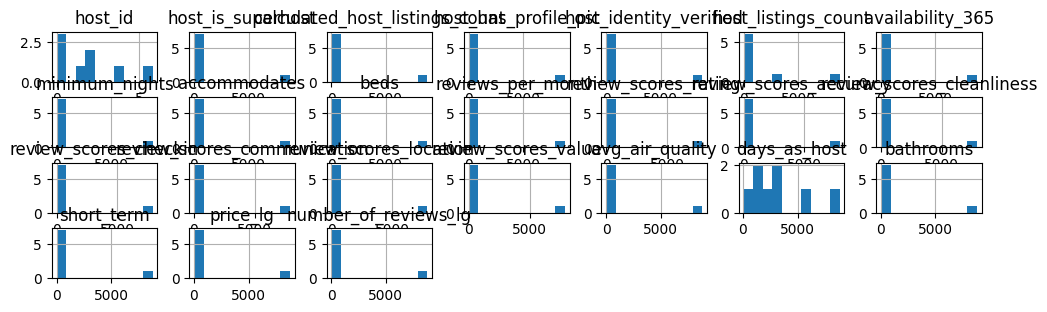

In [ ]:
df_corr.hist(layout = (12, 7), figsize = (12, 10), bins = 10) # adjust parameters as necessary
plt.show()

Most variables do not follow a normal distribution and are heavily right-skewed, particularly variables like price, number_of_reviews, and accommodates. However, variables such as days_as_host and availability_365 appear more evenly distributed and roughly symmetric, so they likely do not require transformation.

**3) Transform the remaining non-normal variables using a square root transformation:**

array([[<Axes: title={'center': 'price_lg'}>,
        <Axes: title={'center': 'number_of_reviews_lg'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'beds'}>],
       [<Axes: title={'center': 'accommodates'}>,
        <Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'host_listings_count'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>],
       [<Axes: title={'center': 'days_as_host'}>,
        <Axes: title={'center': 'availability_365'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'host_is_superhost'}>],
       [<Axes: title={'center': 'host_has_profile_pic'}>,
        <Axes: title={'center': 'host_identity_verified'}>,
        <Axes: title={'center': 'short_term'}>, <Axes: >]], dtype=object)

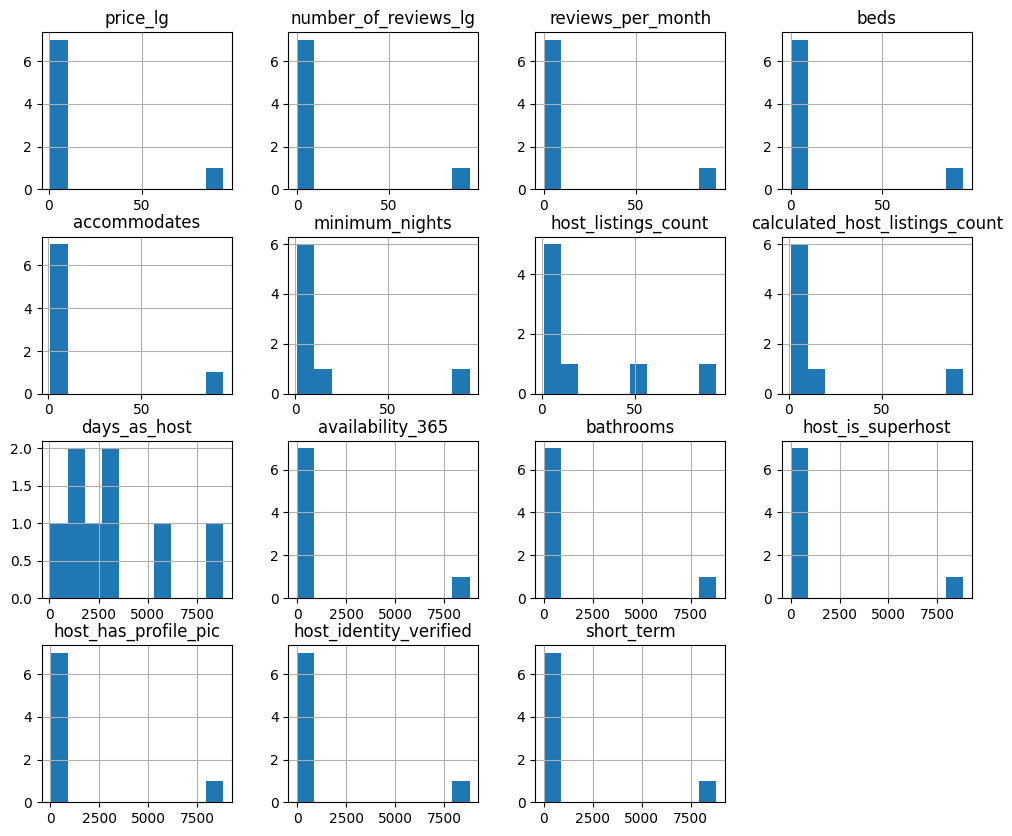

In [ ]:
# create a new dataframe called df_corrT to store your transformed variables
df_corrT = pd.DataFrame()

# create new SQUARE ROOT transformed variables
df_corrT['price_lg'] = np.sqrt(df_corr['price_lg'])
df_corrT['number_of_reviews_lg'] = np.sqrt(df_corr['number_of_reviews_lg'])
df_corrT['reviews_per_month'] = np.sqrt(df_corr['reviews_per_month'])
df_corrT['beds'] = np.sqrt(df_corr['beds'])
df_corrT['accommodates'] = np.sqrt(df_corr['accommodates'])
df_corrT['minimum_nights'] = np.sqrt(df_corr['minimum_nights'])
df_corrT['host_listings_count'] = np.sqrt(df_corr['host_listings_count'])
df_corrT['calculated_host_listings_count'] = np.sqrt(df_corr['calculated_host_listings_count'])

# Add remaining normal vars to df_corrT
df_corrT['days_as_host'] = df_corr['days_as_host']
df_corrT['availability_365'] = df_corr['availability_365']
df_corrT['bathrooms'] = df_corr['bathrooms']

# (optional but good practice) keep binary variables as-is
df_corrT['host_is_superhost'] = df_corr['host_is_superhost']
df_corrT['host_has_profile_pic'] = df_corr['host_has_profile_pic']
df_corrT['host_identity_verified'] = df_corr['host_identity_verified']
df_corrT['short_term'] = df_corr['short_term']

# generate histograms to check transformed variable distributions
df_corrT.hist(figsize=(12,10))

**4) Why would we do a square root transformation on these variables over a log transformation?**

A square root transformation is less aggressive than a log transformation and is appropriate for moderately right-skewed data. It reduces skewness while still preserving the relative differences between values. A log transformation would compress the data more heavily and is typically used for highly skewed distributions, so square root is more appropriate for these variables.

**5) Are there remaining transformed variables that are still not normal AND if so, what is the implication of running parametric analyses (e.g., t-test, pearson correlation)?**

Yes, several variables still do not follow a normal distribution even after the square root transformation. Some variables remain right-skewed, and binary variables (such as host_is_superhost and host_identity_verified) are inherently not normally distributed. This means that using parametric tests like t-tests or Pearson correlation may violate the assumption of normality, which could affect the reliability of the results. In such cases, non-parametric methods or further transformations may be more appropriate.

### **Correlation Analysis**
**6) Let's implement a non-parametric correlation analysis (spearman) on our dataset, then answer why we are doing spearman correlation in place of pearson correlation:**

In [ ]:
# run a spearman correlation analysis on your dataframe, then store values in cor_matrix
# display the formatted matrix (i.e., with background gradient, etc.)
cor_matrix2 = df_corrT.corr(method='spearman')

cor_matrix2.style.background_gradient(cmap='seismic', axis=None, vmin=-1, vmax=1)

,price_lg,number_of_reviews_lg,reviews_per_month,beds,accommodates,minimum_nights,host_listings_count,calculated_host_listings_count,days_as_host,availability_365,bathrooms,host_is_superhost,host_has_profile_pic,host_identity_verified,short_term
price_lg,1.000000,0.976190,0.738095,0.730552,0.952381,0.554257,0.571429,0.610789,0.976190,0.976190,0.904762,0.896127,0.849805,0.849805,0.849805
number_of_reviews_lg,0.976190,1.000000,0.833333,0.814386,0.976190,0.662699,0.690476,0.718576,1.000000,1.000000,0.952381,0.932954,0.875172,0.875172,0.875172
reviews_per_month,0.738095,0.833333,1.000000,0.994030,0.857143,0.891631,0.928571,0.970077,0.833333,0.833333,0.928571,0.822473,0.608816,0.608816,0.608816
beds,0.730552,0.814386,0.994030,1.000000,0.838338,0.896986,0.922172,0.975904,0.814386,0.814386,0.922172,0.827413,0.555053,0.555053,0.555053
accommodates,0.952381,0.976190,0.857143,0.838338,1.000000,0.698846,0.738095,0.742528,0.976190,0.976190,0.976190,0.883852,0.811754,0.811754,0.811754
minimum_nights,0.554257,0.662699,0.891631,0.896986,0.698846,1.000000,0.988024,0.957593,0.662699,0.662699,0.807288,0.708197,0.404378,0.404378,0.404378
host_listings_count,0.571429,0.690476,0.928571,0.922172,0.738095,0.988024,1.000000,0.970077,0.690476,0.690476,0.833333,0.699716,0.456612,0.456612,0.456612
calculated_host_listings_count,0.610789,0.718576,0.970077,0.975904,0.742528,0.957593,0.970077,1.000000,0.718576,0.718576,0.850315,0.753316,0.465734,0.465734,0.465734
days_as_host,0.976190,1.000000,0.833333,0.814386,0.976190,0.662699,0.690476,0.718576,1.000000,1.000000,0.952381,0.932954,0.875172,0.875172,0.875172
availability_365,0.976190,1.000000,0.833333,0.814386,0.976190,0.662699,0.690476,0.718576,1.000000,1.000000,0.952381,0.932954,0.875172,0.875172,0.875172


**Answer**:Spearman correlation is used instead of Pearson correlation because many of the variables in the dataset are not normally distributed, even after transformation. Pearson correlation assumes a linear relationship and normally distributed data, which is not appropriate for skewed variables. Spearman correlation is a non-parametric method that uses rank order, making it more robust to skewed data and able to capture monotonic relationships that are not strictly linear.

**7) Next, lets consider the price variable, which will likely be quite important to Aggie Investments since it's a metric related to revenue. a) Select a variable you think should be related to price (either positively or negatively), b) produce a set of hypotheses, c) then test them!**

* Var 1: Price
* Var 2: Beds

---
* $H_o:$ There is no relationship between price and number of beds (ρ = 0)
* $H_A:$ There is a positive relationship between price and number of beds (ρ > 0)

In [ ]:
# Calculate the Spearman correlation coefficient and p-value for your two variables
corr, p_value = spearmanr(df_corrT['price_lg'], df_corrT['beds'])

# Print the results (pvalue and correlation coefficient)
print('Spearman correlation coefficient:', corr )
print('P-value:', p_value )

alpha = 0.05

if p_value < alpha:
    print('Reject H0: There is a significant positive relationship between price and beds.')
else:
    print('Fail to reject H0: No significant relationship.')



Spearman correlation coefficient: 0.730552019767088
P-value: 0.039555627904297515
Reject H0: There is a significant positive relationship between price and beds.


 **8) How would you describe the strength and direction of the relationship between price and your chosen variable? Is their relationship statistically significant, how do you know?**

There is a significant positive relationship between price and beds. We know this becasue our p_value of 0.039 < 0.05, this means that there is a significant positive relationship and that we should reject the null hypothesis.

**9) If you wanted to train a model to predict price, which 5 other variables would you choose as predictor variables (i.e., which 5 are most strongly correlated with price)?**

1. number_of_reviews_lg  
2. days_as_host  
3. availability_365  
4. accommodates  
5. bathrooms  


### **T Tests**

**Next, let's implement some t-tests to examine potential meaningful group differences in price.**

**10) What variables could we use to group price (hint: remember t-tests can only compare TWO groups)?**

Super-Host

**11) Next, create a set of hypotheses around price and your selected group variable:**

* $H_0$:There is no difference in average price between superhosts and non-superhosts
* $H_A$:There is a difference in average price between superhosts and non-superhosts.

**12) Select the appropriate t-test to examine between group differences based on your selected group variable, then implement below!**

In [ ]:
# run an independent t-test comparing price_lg for your selected grouping variable, produce the t-statistc and p-value
vargroup1 = df_corrT.loc[df_corrT['host_is_superhost'] == True, 'price_lg']
vargroup2 = df_corrT.loc[df_corrT['host_is_superhost'] == False, 'price_lg']

t_statistic, p_value = ttest_ind(vargroup1, vargroup2)

print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 1.6513248147622657
P-value: 0.19723893534209805


In [ ]:
df_corrT['host_is_superhost'] = df_corrT['host_is_superhost'].round()
print(df_corrT['host_is_superhost'].unique())

[8.808e+03 1.000e+00 0.000e+00]


In [ ]:
# Group the data by your chose variable and calculate the mean of 'price_lg' for each group
grouped_mean =df_corrT.groupby('host_is_superhost')['price_lg'].mean()

# Exponentiate the mean values to reverse the log transformormation of price -- puts price back in raw units
exponentiated_mean = np.exp(grouped_mean)

print(exponentiated_mean) # shows the raw average price values

host_is_superhost
0.0       4.751434e+00
1.0       1.157273e+01
8808.0    5.740475e+40
Name: price_lg, dtype: float64


**13) Report on your t-test analysis, including a) can you reject your null hypothesis AND b) if one group is signficantly different than the other, which has higher average price?**

We fail to reject the null hypothesis because the p-value (0.1972) is greater than 0.05, indicating that the difference in average price between superhosts and non-superhosts is not statistically significant. Although superhosts have a slightly higher average price than non-superhosts, this difference is not large enough to conclude that it is meaningful.

## **Association Rules Analysis**

**Next we will further examine meaningful patterns in our dataset by examining what types of qualities within an airbnb property tend to co-occur with good ratings through Association Rules Analysis. This will help our buyers purchase properties that are more likely to be well rated!**

### **Data Preprocessing**



**14) What variable type is required to conduct an association rules analysis?**

Dichotomous variables

**15) Which variables are already dichotomous in this dataset?**

* host_is_superhost
* host_has_profile_pic
* host_identity_varified
* short_term

In [ ]:
# write the id and dichotomous vars into a new dataframe called df_ar
df_ar = df_corrT[['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified','short_term']]
df_ar

,host_is_superhost,host_has_profile_pic,host_identity_verified,short_term
count,8808.0,8808.000000,8808.000000,8808.000000
mean,1.0,0.990577,0.901567,0.869891
std,0.0,0.096620,0.297916,0.336442
min,0.0,0.000000,0.000000,0.000000
25%,0.0,1.000000,1.000000,1.000000
50%,1.0,1.000000,1.000000,1.000000
75%,1.0,1.000000,1.000000,1.000000
max,1.0,1.000000,1.000000,1.000000


**16) Let's not limit ourselves to these few! By discretizing other variables in our dataset, we can convert them to being dichotomous or binominal, and then include them in our analysis. All of our rating variables range between 0-5, what cut-off would you choose if you want to label reviews as good OR not good?**

anything above 3 would be good, vs not good.

**17) Use a cut-off value of 3 to discretize the rating variables `review_scores_rating`, `review_scores_location`, and `review_scores_value` making them dichotomous (good review: 1/0, True/False), such that review scores 3 or above are considered good, and below 3 are not good.**

In [ ]:
# convert the review_ scores variables to binary variables using a cut off of 3, where values under three are  poor (indicated with a 0) and values 3 or greater are good (indicated with a 1), add into df_ar

df_ar['review_scores_rating_good'] = (df['review_scores_rating'] >= 3).astype(int) # I've provided the first variable, this code DOES NOT need to be changed
df_ar['review_scores_value_good'] = (df['review_scores_value'] >= 3).astype(int)
df_ar['review_scores_location_good'] = (df['review_scores_value'] >= 3).astype(int)

df_ar.head()

,host_is_superhost,host_has_profile_pic,host_identity_verified,short_term,review_scores_rating_good,review_scores_value_good,review_scores_location_good
count,8808.0,8808.000000,8808.000000,8808.000000,NaN,NaN,NaN
mean,1.0,0.990577,0.901567,0.869891,NaN,NaN,NaN
std,0.0,0.096620,0.297916,0.336442,NaN,NaN,NaN
min,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,0.0,1.000000,1.000000,1.000000,NaN,NaN,NaN


**18) Next, let's include some other quantitative variables related to the characteristics, including `availability_365`, `accomodates`, `beds`, `bathrooms`, `price_lg`, and `reviews_per_month`. You can also discretize these variables by indicating whether the values are above or below the median value (e.g., 1 if yes, 0 if no).**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8808 entries, 0 to 8807
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      8808 non-null   int64  
 1   id                              8808 non-null   float64
 2   host_id                         8808 non-null   int64  
 3   host_is_superhost               8808 non-null   int64  
 4   calculated_host_listings_count  8808 non-null   int64  
 5   host_has_profile_pic            8808 non-null   int64  
 6   host_identity_verified          8808 non-null   int64  
 7   host_listings_count             8808 non-null   int64  
 8   neighbourhood_cleansed          8808 non-null   object 
 9   availability_365                8808 non-null   int64  
 10  minimum_nights                  8808 non-null   int64  
 11  room_type                       8808 non-null   object 
 12  accommodates                    88

In [ ]:
# create columns to indicate observations with above or equal to median values (0,1)
df_ar['availability_365_abovemed'] =  np.where(df['availability_365'] >= np.median(df['availability_365']) ,1,0) # I've provided the first variable, this code DOES NOT need to be changed
df_ar['accommodates_abovemed'] = np.where(df['accommodates'] >= np.median(df['accommodates']) ,1,0)
df_ar['beds_abovemed'] = np.where(df['beds'] >= np.median(df['beds']) ,1,0)
df_ar['bathrooms_abovemed'] = np.where(df['bathrooms'] >= np.median(df['bathrooms']) ,1,0)
df_ar['price_lg_abovemed'] = np.where(df['price_lg'] >= np.median(df['price_lg']) ,1,0)
df_ar['reviews_per_month_abovemed'] = np.where(df['reviews_per_month'] >= np.median(df['reviews_per_month']) ,1,0)

# create columns to indicate observations with below median values (0,1)
df_ar['availability_365_belowmed'] =  np.where(df['availability_365'] < np.median(df['availability_365']) ,1,0) # I've provided the first variable, this code DOES NOT need to be changed
df_ar['accommodates_belowmed'] =   np.where(df['accommodates'] < np.median(df['accommodates']) ,1,0)
df_ar['beds_belowmed'] = np.where(df['beds'] < np.median(df['beds']) ,1,0)
df_ar['bathrooms_belowmed'] = np.where(df['bathrooms'] < np.median(df['bathrooms']) ,1,0)
df_ar['price_lg_belowmed'] = np.where(df['price_lg'] < np.median(df['price_lg']) ,1,0)
df_ar['reviews_per_month_belowmed'] = np.where(df['reviews_per_month'] < np.median(df['reviews_per_month']) ,1,0)

df_ar.head()

ValueError: Length of values (8808) does not match length of index (8)

### **Association Rules Analysis**
**19) Let's start with generating frequent itemsets from our new dichotomous variables, provide the itemsets with at least TWO items that have the three highest support values. Indicate a) the itemset and b) the support value. Set your `min_support` value to `0.3.`**

In [ ]:
 # set id as the index
 df_ar.head()

,host_is_superhost,host_has_profile_pic,host_identity_verified,short_term,review_scores_rating_good,review_scores_value_good,review_scores_location_good
count,8808.0,8808.000000,8808.000000,8808.000000,NaN,NaN,NaN
mean,1.0,0.990577,0.901567,0.869891,NaN,NaN,NaN
std,0.0,0.096620,0.297916,0.336442,NaN,NaN,NaN
min,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,0.0,1.000000,1.000000,1.000000,NaN,NaN,NaN


In [ ]:
# use apriori function to generate frequent itemsets with a min_suport of 0.3, assign values to freq_rs
freq_rs = apriori(df_ar, min_support=0.3, use_colnames=True)
freq_rs = freq_rs.sort_values(by='support', ascending=False)
freq_rs_2 = freq_rs[freq_rs['itemsets'].apply(lambda x: len(x) >= 2)]

freq_rs

ValueError: NaN values are not permitted in the DataFrame when null_values=False.

1. Itemset 1: ({'host_identity_verified', 'host_has_profile_pic'}), support = 0.895
2. Itemset 2: ({'review_scores_location_good', 'review_scores_value_good'}), support = 0.8923
3. Itemset 3: ({'review_scores_rating_good', 'review_scores_value_good'}), support = 0.8919


**20) What does the support measure for an itemset? Provide an interpretation for one of your itemsets above that includes the support value.**

The itemset {host_identity_verified, host_has_profile_pic} has a support value of 0.894982, which means that approximately 89.5% of listings in the dataset have both a verified host identity and a profile picture. This indicates that these two features commonly occur together.

**21) Now, let's take this frequent itemsets and generate some association rules! Using your freq_rs, generate rules with a `min_threshold = 0.3`.**

In [ ]:
# run association rules on frequent itemsets with a min_threshold of confidence of 0.3, assign values to ar_table
ar_table = association_rules(freq_rs, metric = "confidence", min_threshold = 0.3)
# display the table
ar_table

**22) Identify the association rule with the highest Lift where `review_scores_rating_good` is in the consequent AND the antecedent contains at least one variable that is NOT another `review` variable (e.g., should be a variable about the host or property characteristics). What does this rule mean?**

The lift is 1.88046

This rule indicates that listings with good location ratings, above-median accommodation capacity, and above-median price are very likely to also have good overall ratings, along with other positive attributes such as having a host profile picture, good value ratings, and above-median bathrooms. The lift value of 1.88 suggests that this combination of characteristics increases the likelihood of a high overall rating compared to what would be expected by chance.

**23) Choose three association rules you think are particularly insightful or suprising, that you would like to report to Aggie Investments. Then a) provide the full rule {Antecedent itemset} → {Consequent itemset} with b) it's confidence and lift values.**



1. {'insert antecdent'} → {'insert consequent'}, cofindence = , lift =
2. Association rule 2, confidence and lift
3. Association rule 3, confidence and lift

**24) Choose one rule from above, a) interpret its lift and confidence values (what do they mean, practically) and b) explain why would this be an interesting rule to share with Aggie Investments? *(Hint: Lots of the rules with the highest confidence/lift values are common sense, are there any associations that are less obvious? It's fine if they don't have the highest lift or confidence values.)*.**

## **Clustering Analysis**

**We will perform our last analysis, KMeans clustering, in order to make final recommendations on segments (or clusters) of properties that Aggie Investments should invest in. This way, when Aggie Investments encounters potential properties in the future, they can decide whether it should be purchased or not, based on how the property fits in with its existing data on property segments.**

**Let's begin by preprocessing the data for KMeans:**

### **Data Preprocessing**

**25) Begin by creating a new version of your dataframe that only contains the features to be analyzed (drop `id`, `host_id`, and `Unnamed: 0`).**

In [ ]:
# copy dataframe and store as features
features =
# drop variables from features
features =
features.head()

**26) Now let's further reduce down our features by excluding redundant variables as well as nominal variables with many levels. Subset your dataset to only include: `host_is_superhost`, `availability_365`, `short_term`, `accommodates`, `bathrooms`, `price_lg`, `room_type`, `beds`, `review_scores_rating`, and `avg_air_quality`. Why is it important to remove redundant variables before performing a clustering analysis?**

In [ ]:
# reduce down features to the above mentioned select variables
features =
features.head()

**Answer**:

**27) Peform the remaining data preprocessing steps including dummy coding the a) qualitative variables b) dropping remaining missing data from the reviews column, and c) scaling all variables. What is the purpose of scaling variables before performing a clustering analysis?**

**Answer**:

In [ ]:
features = pd.get_dummies(features) # dummy code any qualitative variables
# drop remaining missing values from the review_scores_rating column

In [ ]:
# load in the standardscaler function
# apply to features, store as scaled_features
scaled_features

### **KMeans Clustering**

**28) Using the elbow rule and the knee locator function, determine the optimal number of clusters, then run a KMeans using the final number of clusters. Use the following parameters in your `kmeans_kwargs` `init: 'random'`, `n_init: 10`, `max_iter: 300`, `random_state: 42`, set your k range as (1,11).**

In [ ]:
# set up kmeans_kwargs dictionary


# create empty list for SSE values
# run forloop on KMeans to try out a range of values for K, 1-11

In [ ]:
# plot the elbow curve

In [ ]:
# apply the knee locator function to indicate the optimal number of clusters

In [ ]:
# run KMeans using the optimal number of clusters
#fit KMeans to data

**29) How many clusters were deemed optimal? Explain how the elbow rule is used to determine the optimal number of clusters?**

**30) Next, create a centroid table and use the centroid values to produce labels for each of your clusters of properties. For each label, provide a brief explanation for the title you've created.**

In [ ]:
# save cluster centroids to an object called 'centroids'
# create centroid table from centroids
# display table



*   **Cluster_0 label:**
*  **Cluster_1 label:**
*   **Cluster_2 label:**
*   **Cluster_3 label:**
*   **Cluster_4 label:**
*   **Cluster_5 label:**


**31) If you were to encourage Aggie Investments to invest in a particular segment (cluster) of properties, which cluster would you choose and why?**

**32) Finally, create a visualization to back-up your property cluster recommendation. Include a description of the visualization to indicate how it supports your claim.**

In [ ]:
# produce visualization to highlight why your cluster is the best!

**Description**:

## **Summarize findings**

**33) Briefly summarize what you learned from this analysis to a non-statistician. Write a few sentences about 1) the purpose of the analyses conducted and 2) what you learned about this data set from your analyses. Write your response as if you were addressing a business manager (avoid using statistics jargon) and provide the main take-aways:**